# Injection Molding Defect Prediction - EDA

## What is an injection molding machine?

An injection molding machine makes plastic parts by melting plastic and pushing it into a mold, a bit like a high tech waffle iron. Almost everything plastic around you (bottle caps, phone cases, car light lenses) is made this way.

![Injection molding machine on a factory floor](../images/machine_photo.jpg)

*A real injection molding machine on a factory floor. The blue trays on the conveyor are the parts it just produced, and the white arm is a robot that removes them.*

### How it works, step by step

![How the plastic fills the mold](../images/machine_diagram.png)

1. **Feed** - small plastic pellets are poured into the top of the machine.
2. **Melt** - a heated screw turns and melts the pellets into a thick liquid, like melted chocolate.
3. **Inject** - the machine pushes that melted plastic, under high pressure, through a nozzle into a metal mold shaped like the part (the diagram shows the plastic, in blue, flowing in).
4. **Cool** - the plastic cools inside the mold and hardens into the part's shape.
5. **Eject** - the mold opens and ejector pins push the finished part out. Then it starts again. Each repeat is one **cycle**, and the machine makes one part per cycle.

Every cycle, the machine records its own settings: how hot the plastic was, how much pressure it used, how long the cycle took, and so on. These recorded settings are called **process parameters**, and they are the data I work with.

## The problem I am solving

Sometimes a cycle produces a **defective part** (warped, incomplete, or the wrong shape). Today, factories usually only catch these later during inspection, after the material and machine time are already wasted.

The idea of this project is to use the machine's own recorded settings to predict, right away, whether a part is **good or scrap**, and eventually which setting caused the problem, so an operator can fix the machine before making more bad parts.

## This notebook

This is the exploration step. Before building any model, I look at the data: how big it is, whether it is clean, how many parts are good versus scrap, how the settings are spread out, and whether the settings actually differ between good and scrap parts. What I find here decides what I do in the modeling step.

The dataset is real production data from a plastics company (iGuzzini), 1,451 molding cycles, 13 process parameters per cycle, and a quality label.

*Image credits: machine photo and mold diagram from Wikimedia Commons, used under CC BY-SA.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 1. Load the data

The file is separated by semicolons, so I tell pandas `sep=';'`. Each row is one molding cycle. The last column, `quality`, is the label I want to predict.

In [2]:
df = pd.read_csv('../data/raw/injection_molding.csv', sep=';')
print('Rows, columns:', df.shape)
df.head()

Rows, columns: (1451, 14)


,Melt temperature,Mold temperature,time_to_fill,ZDx - Plasticizing time,ZUx - Cycle time,SKx - Closing force,SKs - Clamping force peak value,Ms - Torque peak value current cycle,Mm - Torque mean value current cycle,APSs - Specific back pressure peak value,APVs - Specific injection pressure peak value,CPn - Screw position at the end of hold pressure,SVo - Shot volume,quality
0,106.476184,80.617,7.124,3.16,74.83,886.900000,904.000000,116.9,104.300000,145.6,922.3,8.82,18.73,1.0
1,105.505000,81.362,6.968,3.16,74.81,919.409791,935.900000,113.9,104.900000,145.6,930.5,8.59,18.73,1.0
2,105.505000,80.411,6.864,4.08,74.81,908.600000,902.344823,120.5,106.503496,147.0,933.1,8.80,18.98,1.0
3,106.474827,81.162,6.864,3.16,74.82,879.410871,902.033653,127.3,104.900000,145.6,922.3,8.85,18.73,1.0
4,106.466140,81.471,6.864,3.22,74.83,885.644260,902.821269,120.5,106.700000,145.6,917.5,8.80,18.75,1.0


The column names are long machine codes that are hard to read, so I rename them to short plain names. They mean the same thing, just easier to follow.

In [3]:
rename = {
    'Melt temperature': 'melt_temp',
    'Mold temperature': 'mold_temp',
    'time_to_fill': 'fill_time',
    'ZDx - Plasticizing time': 'plasticizing_time',
    'ZUx - Cycle time': 'cycle_time',
    'SKx - Closing force': 'closing_force',
    'SKs - Clamping force peak value': 'clamping_force',
    'Ms - Torque peak value current cycle': 'torque_peak',
    'Mm - Torque mean value current cycle': 'torque_mean',
    'APSs - Specific back pressure peak value': 'back_pressure',
    'APVs - Specific injection pressure peak value': 'injection_pressure',
    'CPn - Screw position at the end of hold pressure': 'screw_position',
    'SVo - Shot volume': 'shot_volume',
}
df = df.rename(columns=rename)
features = list(rename.values())
print('The 13 process parameters:')
for f in features:
    print(' -', f)

The 13 process parameters:
 - melt_temp
 - mold_temp
 - fill_time
 - plasticizing_time
 - cycle_time
 - closing_force
 - clamping_force
 - torque_peak
 - torque_mean
 - back_pressure
 - injection_pressure
 - screw_position
 - shot_volume


## 2. Is the data clean?

I check the data types, missing values, and duplicate rows. If there were gaps or wrong types I would need to fix them before modeling.

In [4]:
print('Missing values in total:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Column types:')
print(df.dtypes.value_counts())

Missing values in total: 0
Duplicate rows: 0
Column types:
float64    14
Name: count, dtype: int64


Everything is a number, there are no missing values, and no duplicate rows. So this dataset needs no cleaning or filling in. That is because it is curated production data, not a raw factory dump.

## 3. The target: good vs scrap

The `quality` column originally grades each part 1 to 4 (1 = waste/scrap, 2 = acceptable, 3 = target/best, 4 = over quality). For this project the question I care about is simpler: is the part **good** or is it **scrap**. So I turn it into a yes/no label:

- scrap = 1 (the waste grade, label 1)
- good = 0 (everything that passed, labels 2, 3, 4)

Then I check how many of each I have. This matters because if scrap was very rare, accuracy would be a misleading score.

Good parts (0): 1081
Scrap parts (1): 370
Scrap rate: 25.5 %


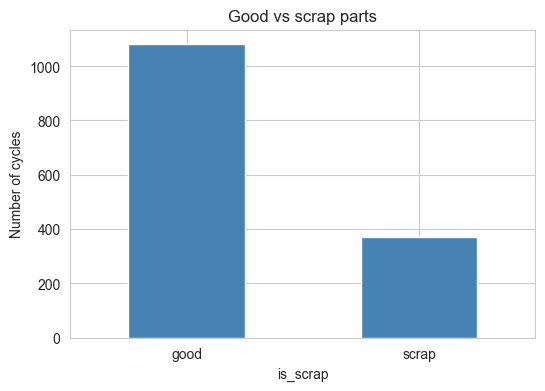

In [5]:
df['quality'] = df['quality'].astype(int)
df['is_scrap'] = (df['quality'] == 1).astype(int)

counts = df['is_scrap'].value_counts()
print('Good parts (0):', counts[0])
print('Scrap parts (1):', counts[1])
print('Scrap rate:', round(df['is_scrap'].mean() * 100, 1), '%')

plt.figure(figsize=(6, 4))
df['is_scrap'].map({0: 'good', 1: 'scrap'}).value_counts().plot(kind='bar', color='steelblue')
plt.title('Good vs scrap parts')
plt.ylabel('Number of cycles')
plt.xticks(rotation=0)
plt.show()

About a quarter of the parts are scrap and three quarters are good. That is not perfectly balanced but it is not extreme either, so a model has enough examples of both. I will still report precision, recall and F1, not just accuracy, because catching scrap is the whole point.

## 4. Summary statistics

`describe()` shows the average, smallest, largest and spread of each parameter. I am mainly looking at the scale of each column.

In [6]:
df[features].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
melt_temp,106.892040,5.615773,81.747,155.032
mold_temp,81.326023,0.428813,78.409,82.159
fill_time,7.459043,1.688106,6.084,11.232
plasticizing_time,3.234173,0.343230,2.780,6.610
cycle_time,75.218794,0.432761,74.780,75.790
closing_force,901.974834,11.098192,876.700,930.600
clamping_force,919.351778,10.780023,894.800,946.500
torque_peak,116.716747,5.029085,94.200,130.300
torque_mean,104.163904,4.802195,76.500,114.900
back_pressure,146.230048,0.804894,144.800,150.500


The parameters are on very different scales. Forces and pressures are in the hundreds (closing force, injection pressure), while shot volume and plasticizing time are in single digits. This matters because a scale sensitive model like a Support Vector Machine would let the big-number columns dominate the small ones. So before those models I will scale the features with StandardScaler (put them all on the same scale). Tree based models like XGBoost do not need scaling.

## 5. How are the parameters spread out?

I plot a histogram of each parameter to see its shape: is it bell shaped, lopsided (skewed), or does it have odd outliers. A histogram just counts how many cycles fall in each value range.

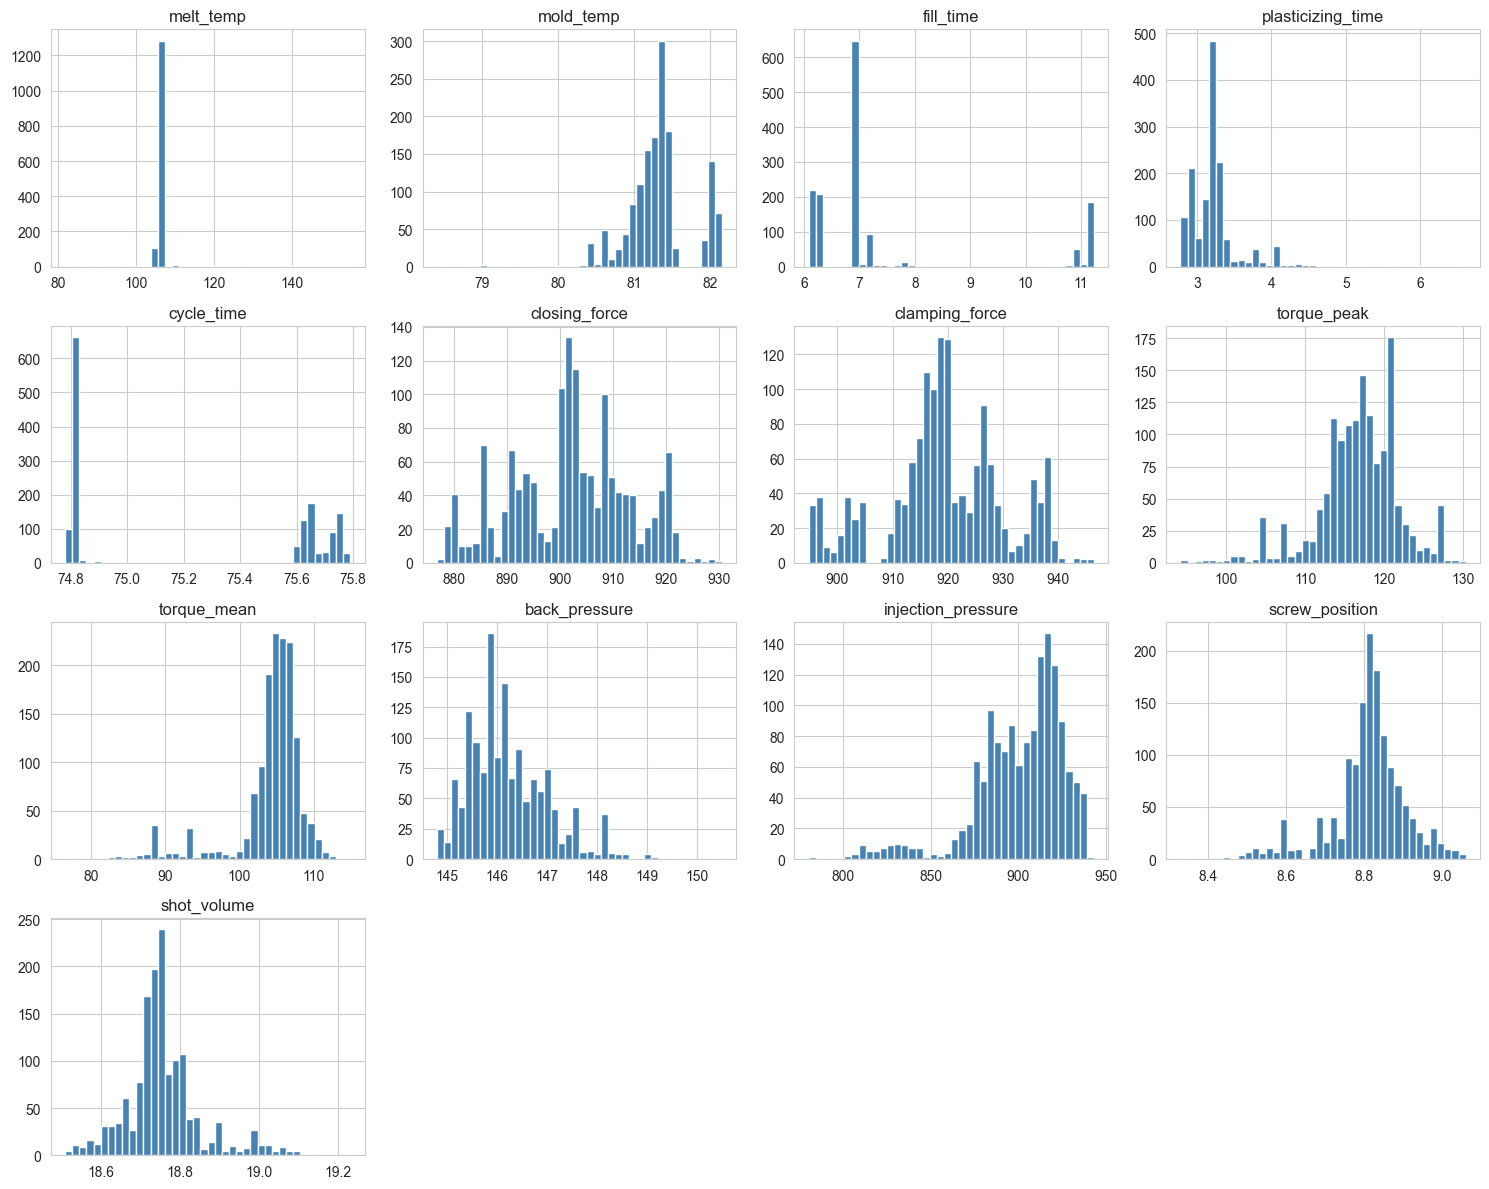

In [7]:
df[features].hist(bins=40, figsize=(15, 12), color='steelblue', edgecolor='white')
plt.tight_layout()
plt.show()

Most parameters are clustered tightly around one value, which makes sense because the machine runs at a fairly steady setting. A few, like melt temperature, have a long tail caused by a small number of unusual cycles. I checked the shapes first instead of transforming anything blindly. Because my main models are tree based (which do not care about skew), I leave the parameters as they are for now and only revisit a transform if the linear model struggles.

## 6. Which parameters move together?

A correlation heatmap shows which parameters rise and fall together. A value near 1 means two parameters carry almost the same information. This is useful to know before modeling.

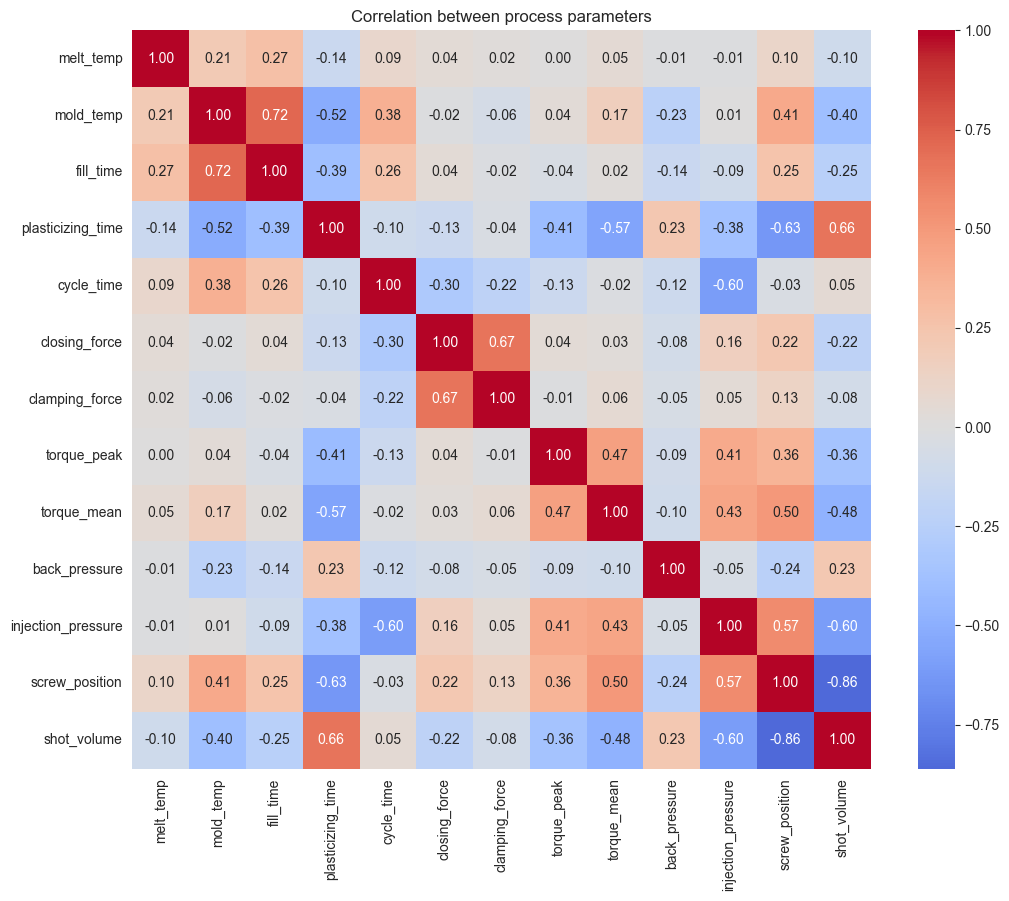

In [8]:
plt.figure(figsize=(11, 9))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation between process parameters')
plt.tight_layout()
plt.show()

The strongest link is screw position and shot volume at about -0.86. The minus sign means it is an inverse relationship: cycles with a higher screw position tend to have a lower shot volume, and the other way round. That makes sense because both describe the same thing from opposite ends, how much material is left versus how much was injected. Even so, no pair is a perfect copy (a perfect copy would be 1.00 or -1.00), so I do not need to drop any column. I keep all 13 parameters.

## 7. Do the parameters differ between good and scrap?

This is the most important question. If good and scrap parts have the same parameter values, no model can tell them apart. So I draw box plots of each parameter split by good vs scrap. If the two boxes sit at clearly different heights, that parameter helps predict scrap.

C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])


C:\Users\Admin\AppData\Local\Temp\ipykernel_104480\1700942268.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['good', 'scrap'])


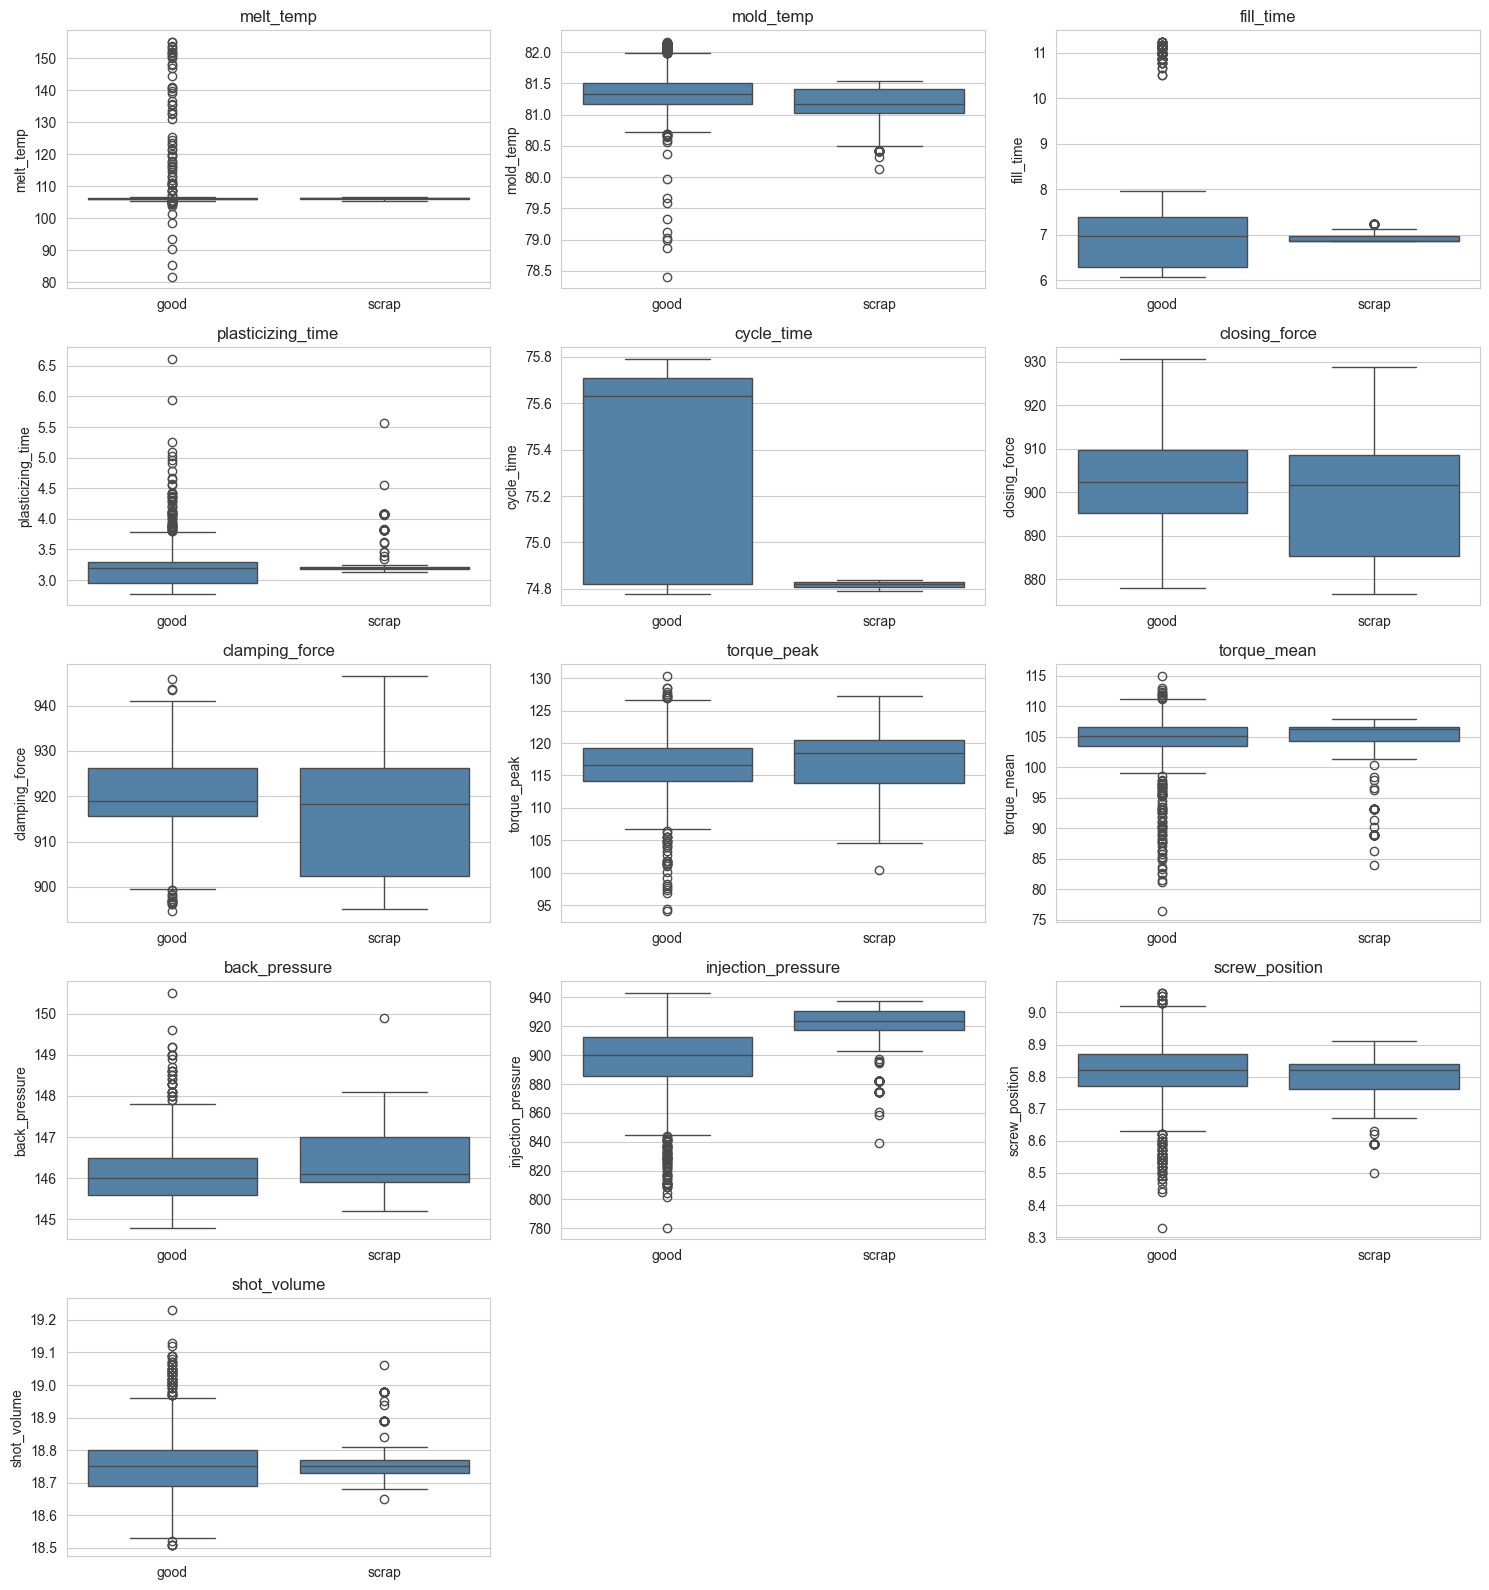

In [9]:
fig, axes = plt.subplots(5, 3, figsize=(15, 16))
axes = axes.ravel()
for i, col in enumerate(features):
    sns.boxplot(x='is_scrap', y=col, data=df, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xticklabels(['good', 'scrap'])
    axes[i].set_xlabel('')
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

Several parameters clearly differ between good and scrap parts. Cycle time is the most obvious one, the good and scrap boxes barely overlap, and mold temperature, fill time and injection pressure also separate well. That is a good sign: there is real signal here, so a model should be able to learn the difference. A few parameters like torque and melt temperature overlap a lot, so they carry less information on their own.

## 8. Summary

What I found and what it means for the next step:

1. The data is small but clean: 1,451 cycles, 13 numeric parameters, no missing values, no duplicates. No cleaning needed.
2. About 25% of parts are scrap and 75% are good. Not extreme, but I will report precision, recall and F1, not just accuracy.
3. The parameters are on very different scales, so I will scale them before any model that is sensitive to scale.
4. Some parameters are skewed but I leave them for now.
5. Good and scrap parts clearly differ on several parameters, especially cycle time, so there is real signal for a model to learn.

Next step is the modeling notebook. First I test whether the two classes can be split by a simple straight line (linear separability). If a straight line is not enough, that justifies moving to stronger models: a Support Vector Machine with a curved boundary and XGBoost. I then explain the best model with SHAP, so I can point to the exact setting that caused a part to be scrap, and add anomaly detection to catch unusual cycles even without a label.